# Snow Pole Detection - Testing on Road_poles_iPhone Test Set

Test trained YOLO model on Road_poles_iPhone test dataset with comprehensive evaluations.

**Model trained on:** roadpoles_v1 + Road_poles_iPhone
**Testing on:** Road_poles_iPhone test set

## 1. Setup & Configuration

In [2]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import pandas as pd
from tqdm import tqdm
import json
from datetime import datetime
import random

# YOLO
from ultralytics import YOLO

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# ============================================================
# CONFIGURATION - Adjust these paths!
# ============================================================

# Path to your trained model weights
MODEL_PATH = Path("runs/snowpole_detection/yolo11n_20251122_115057/weights/best.pt")
# MODEL_PATH = Path("runs/snowpole_detection/yolov9t_20251122_131149/weights/best.pt")
# MODEL_PATH = Path("runs/snowpole_detection/yolov8n_20251122_125030/weights/best.pt")

# Dataset path
BASE_PATH = Path("/datasets/tdt4265/Poles2025")
# For IDUN cluster:
# BASE_PATH = Path("/cluster/projects/vc/courses/TDT17/ad/Poles2025")

# Road_poles_iPhone test set structure
TEST_IMAGES_PATH = BASE_PATH / "Road_poles_iPhone" / "images" / "Test" / "test"
TEST_LABELS_PATH = BASE_PATH / "Road_poles_iPhone" / "labels" / "Test" / "test"

# Output directory
OUTPUT_DIR = Path("road_poles_iphone_test_results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Inference settings
CONF_THRESHOLD = 0.25  # Confidence threshold
IOU_THRESHOLD = 0.45   # IoU threshold for NMS
IMG_SIZE = 1280        # Should match training size

print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Test images path: {TEST_IMAGES_PATH}")
print(f"Test images exist: {TEST_IMAGES_PATH.exists()}")
print(f"Test labels path: {TEST_LABELS_PATH}")
print(f"Test labels exist: {TEST_LABELS_PATH.exists()}")
print(f"Output directory: {OUTPUT_DIR}")

Model path: runs/snowpole_detection/yolo11n_20251122_115057/weights/best.pt
Model exists: True
Test images path: /datasets/tdt4265/Poles2025/Road_poles_iPhone/images/Test/test
Test images exist: True
Test labels path: /datasets/tdt4265/Poles2025/Road_poles_iPhone/labels/Test/test
Test labels exist: False
Output directory: road_poles_iphone_test_results


In [4]:
# Load model
try:
    model = YOLO(str(MODEL_PATH))
    print(f"✓ Model loaded successfully")
    print(f"  Model: {MODEL_PATH.stem}")
except Exception as e:
    print(f"✗ Error loading model: {e}")
    model = None

✓ Model loaded successfully
  Model: best


In [5]:
# Verify dataset structure
if TEST_IMAGES_PATH.exists():
    image_files = sorted(list(TEST_IMAGES_PATH.glob("*.jpg")) + list(TEST_IMAGES_PATH.glob("*.png")))
    print(f"Found {len(image_files)} images in test set")
else:
    print(f"⚠️ Test images path not found: {TEST_IMAGES_PATH}")
    image_files = []

if TEST_LABELS_PATH.exists():
    label_files = sorted(list(TEST_LABELS_PATH.glob("*.txt")))
    print(f"Found {len(label_files)} labels in test set")
else:
    print(f"⚠️ Test labels path not found: {TEST_LABELS_PATH}")
    label_files = []

Found 138 images in test set
⚠️ Test labels path not found: /datasets/tdt4265/Poles2025/Road_poles_iPhone/labels/Test/test


## 2. Load Ground Truth Labels

In [6]:
def load_yolo_labels(label_path):
    """
    Load YOLO format labels (normalized coords).
    Returns list of boxes in format: [x_center, y_center, width, height, class_id]
    """
    boxes = []
    if not label_path.exists():
        return boxes
    
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 5:
                try:
                    box = [float(p) for p in parts[:5]]
                    boxes.append(box)
                except ValueError:
                    continue
    
    return boxes

def normalize_to_pixel_coords(box, img_width, img_height):
    """
    Convert normalized YOLO coords to pixel coords.
    Input: [x_center, y_center, width, height] (normalized)
    Output: [x1, y1, x2, y2] (pixel coords)
    """
    x_center_norm, y_center_norm, width_norm, height_norm = box[:4]
    
    x_center = x_center_norm * img_width
    y_center = y_center_norm * img_height
    width = width_norm * img_width
    height = height_norm * img_height
    
    x1 = max(0, x_center - width / 2)
    y1 = max(0, y_center - height / 2)
    x2 = min(img_width, x_center + width / 2)
    y2 = min(img_height, y_center + height / 2)
    
    return [x1, y1, x2, y2]

print("Label loading functions defined ✓")

Label loading functions defined ✓


## 3. Run Inference on Test Set

In [7]:
def run_inference_on_test_set(model, image_dir, conf_threshold=0.25, iou_threshold=0.45, img_size=1280):
    """
    Run inference on all images in test set.
    Returns structured results with predictions and statistics.
    """
    if not model:
        print("✗ Model not loaded!")
        return None
    
    image_files = sorted(list(image_dir.glob("*.jpg")) + list(image_dir.glob("*.png")))
    
    if not image_files:
        print(f"✗ No images found in {image_dir}")
        return None
    
    print(f"Running inference on {len(image_files)} images...\n")
    
    results_data = {
        'results': [],
        'detection_counts': [],
        'confidences': [],
    }
    
    for i, img_path in enumerate(tqdm(image_files)):
        # Run YOLO inference
        result = model.predict(
            source=str(img_path),
            conf=conf_threshold,
            iou=iou_threshold,
            imgsz=img_size,
            verbose=False
        )[0]
        
        # Parse detections
        boxes = []
        confs = []
        
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                conf = float(box.conf[0].cpu().numpy())
                
                boxes.append({
                    'xyxy': xyxy,
                    'conf': conf,
                })
                confs.append(conf)
        
        results_data['results'].append({
            'image_name': img_path.name,
            'image_path': str(img_path),
            'boxes': boxes,
            'n_detections': len(boxes),
        })
        
        results_data['detection_counts'].append(len(boxes))
        results_data['confidences'].extend(confs)
    
    return results_data

# Run inference
if model and TEST_IMAGES_PATH.exists():
    inference_data = run_inference_on_test_set(
        model, 
        TEST_IMAGES_PATH,
        conf_threshold=CONF_THRESHOLD,
        iou_threshold=IOU_THRESHOLD,
        img_size=IMG_SIZE
    )
else:
    inference_data = None

Running inference on 138 images...



100%|██████████| 138/138 [00:02<00:00, 52.19it/s]


## 4. Visualizations

✓ Saved: detection_statistics.png


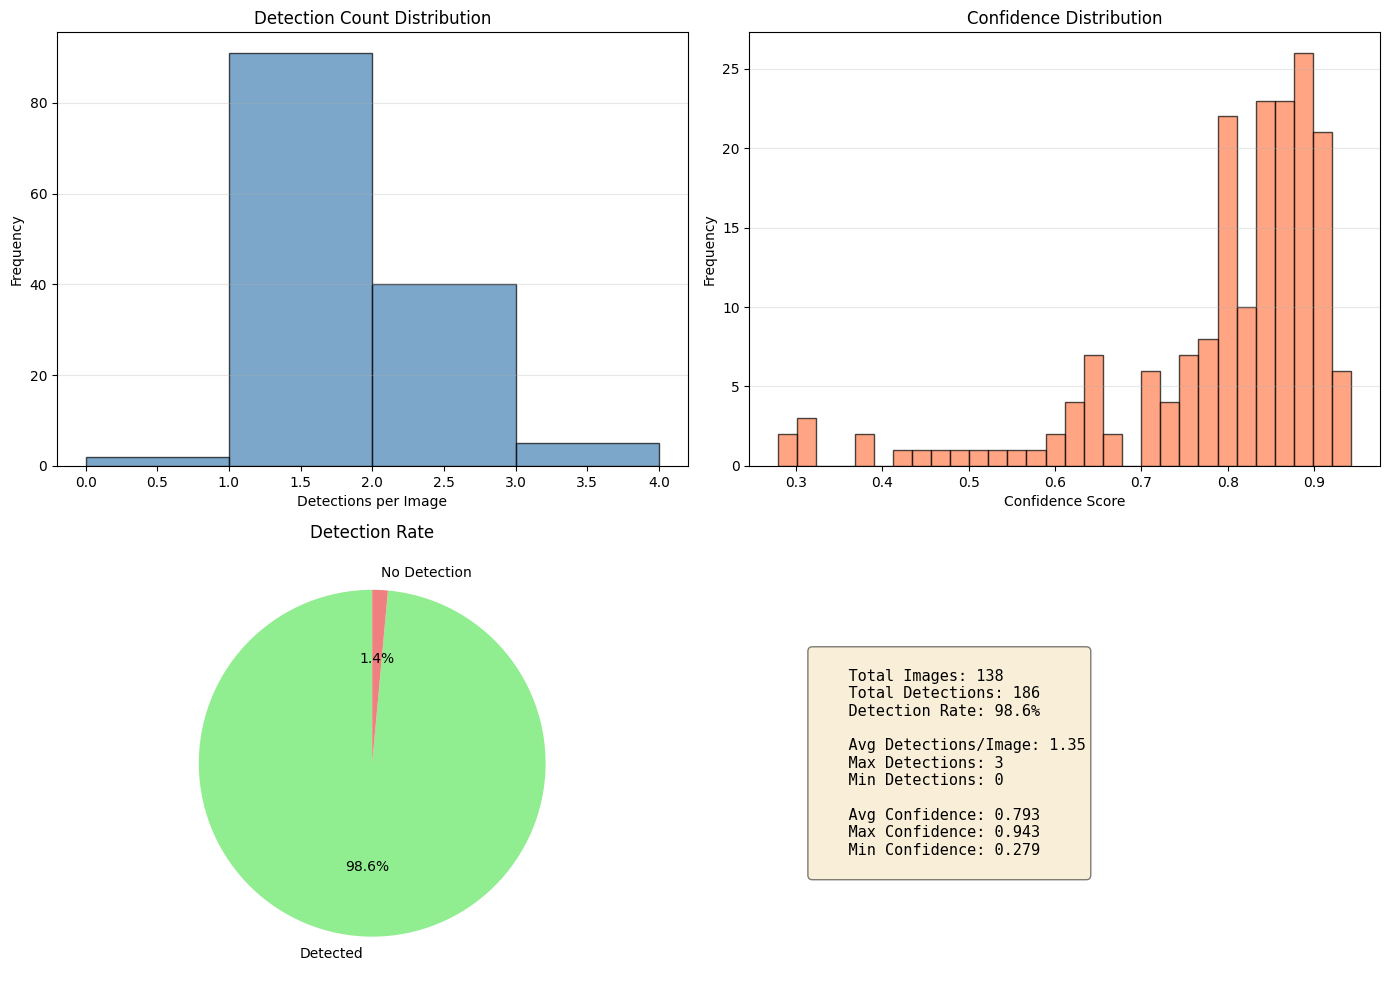

In [8]:
# Detection statistics visualization
if inference_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Detection count distribution
    ax = axes[0, 0]
    dc = inference_data['detection_counts']
    ax.hist(dc, bins=range(0, max(dc) + 2), edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel('Detections per Image')
    ax.set_ylabel('Frequency')
    ax.set_title('Detection Count Distribution')
    ax.grid(axis='y', alpha=0.3)
    
    # Confidence distribution
    ax = axes[0, 1]
    conf = inference_data['confidences']
    if conf:
        ax.hist(conf, bins=30, edgecolor='black', alpha=0.7, color='coral')
        ax.set_xlabel('Confidence Score')
        ax.set_ylabel('Frequency')
        ax.set_title('Confidence Distribution')
        ax.grid(axis='y', alpha=0.3)
    
    # Detection rate
    ax = axes[1, 0]
    detected = sum(1 for c in dc if c > 0)
    not_detected = len(dc) - detected
    ax.pie([detected, not_detected], labels=['Detected', 'No Detection'], 
           autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
    ax.set_title('Detection Rate')
    
    # Statistics table
    ax = axes[1, 1]
    ax.axis('off')
    
    stats_text = f"""
    Total Images: {len(dc)}
    Total Detections: {sum(dc)}
    Detection Rate: {detected / len(dc) * 100:.1f}%
    
    Avg Detections/Image: {np.mean(dc):.2f}
    Max Detections: {max(dc) if dc else 0}
    Min Detections: {min(dc) if dc else 0}
    
    Avg Confidence: {np.mean(conf) if conf else 0:.3f}
    Max Confidence: {max(conf) if conf else 0:.3f}
    Min Confidence: {min(conf) if conf else 0:.3f}
    """
    
    ax.text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'detection_statistics.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved: detection_statistics.png")
    plt.show()

✓ Saved: sample_detections.png


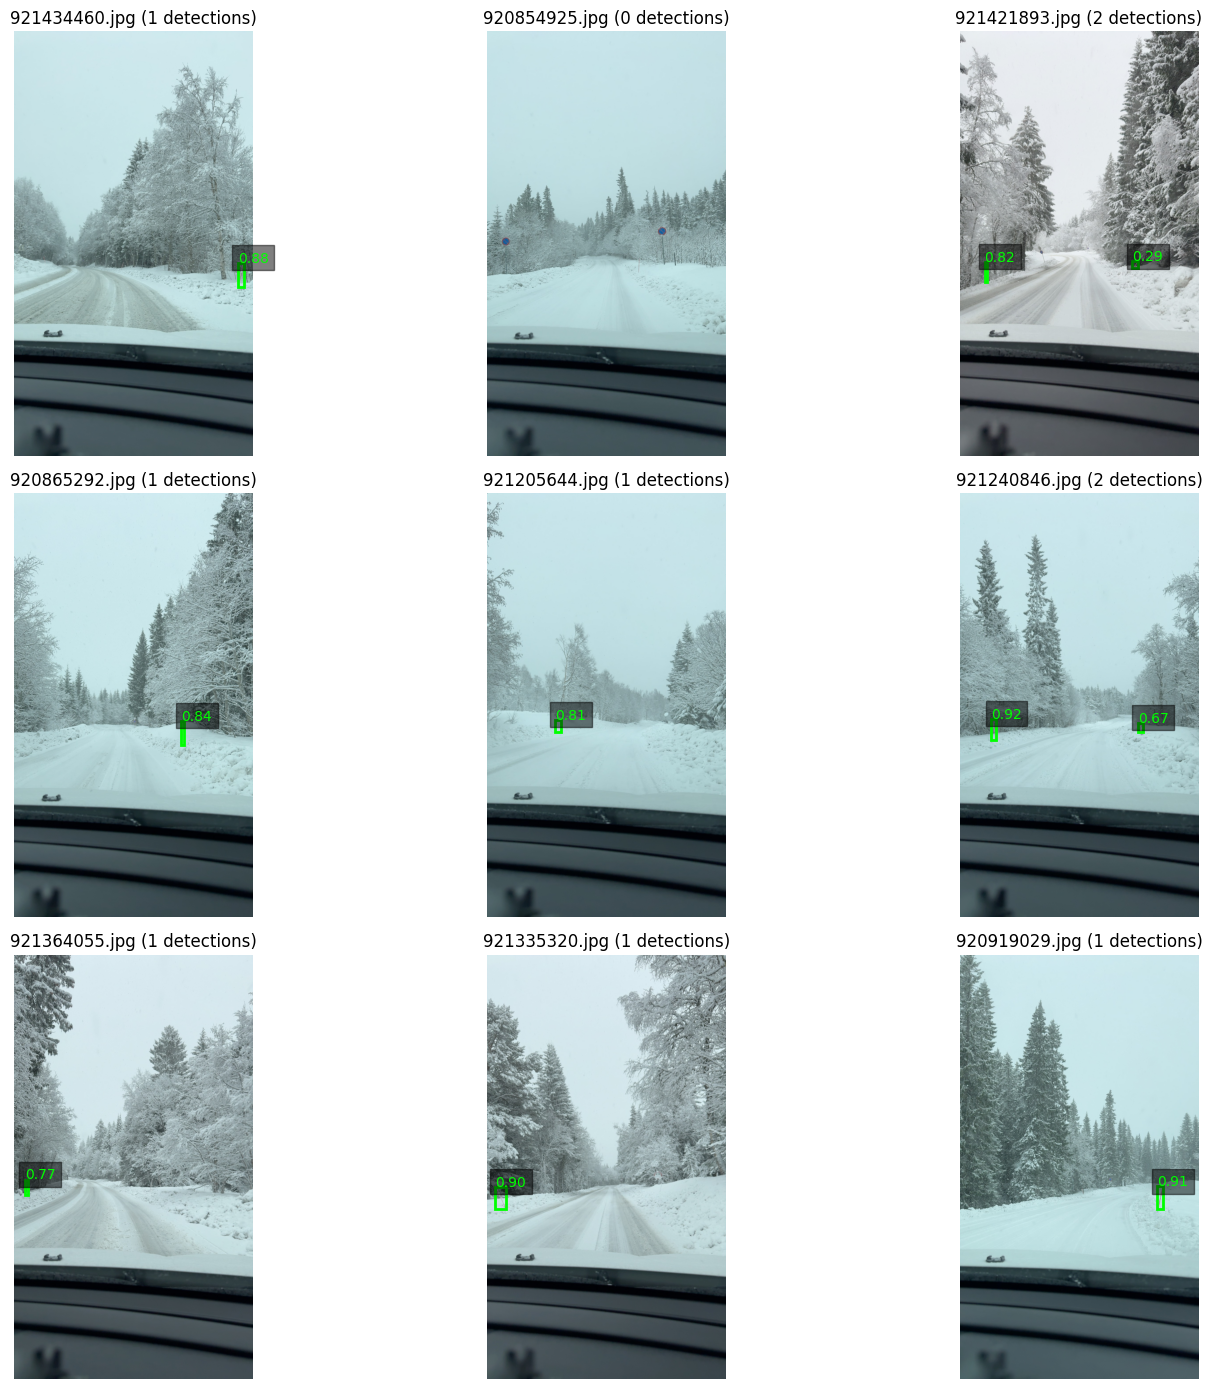

In [9]:
# Sample detections visualization
if inference_data:
    fig, axes = plt.subplots(3, 3, figsize=(16, 14))
    axes = axes.flatten()
    
    samples = random.sample(inference_data['results'], min(9, len(inference_data['results'])))
    
    for idx, result in enumerate(samples):
        ax = axes[idx]
        
        # Load and display image
        img = cv2.imread(result['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        
        # Draw detections
        for box in result['boxes']:
            xyxy = box['xyxy']
            conf = box['conf']
            
            x1, y1, x2, y2 = int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3])
            
            # Draw bounding box
            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       fill=False, edgecolor='lime', linewidth=2))
            # Draw confidence
            ax.text(x1, y1-5, f'{conf:.2f}', color='lime', fontsize=10, 
                   bbox=dict(facecolor='black', alpha=0.5))
        
        ax.set_title(f"{result['image_name']} ({result['n_detections']} detections)")
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_detections.png', dpi=150, bbox_inches='tight')
    print(f"✓ Saved: sample_detections.png")
    plt.show()

✓ Saved: no_detections.png (2 images without detections)


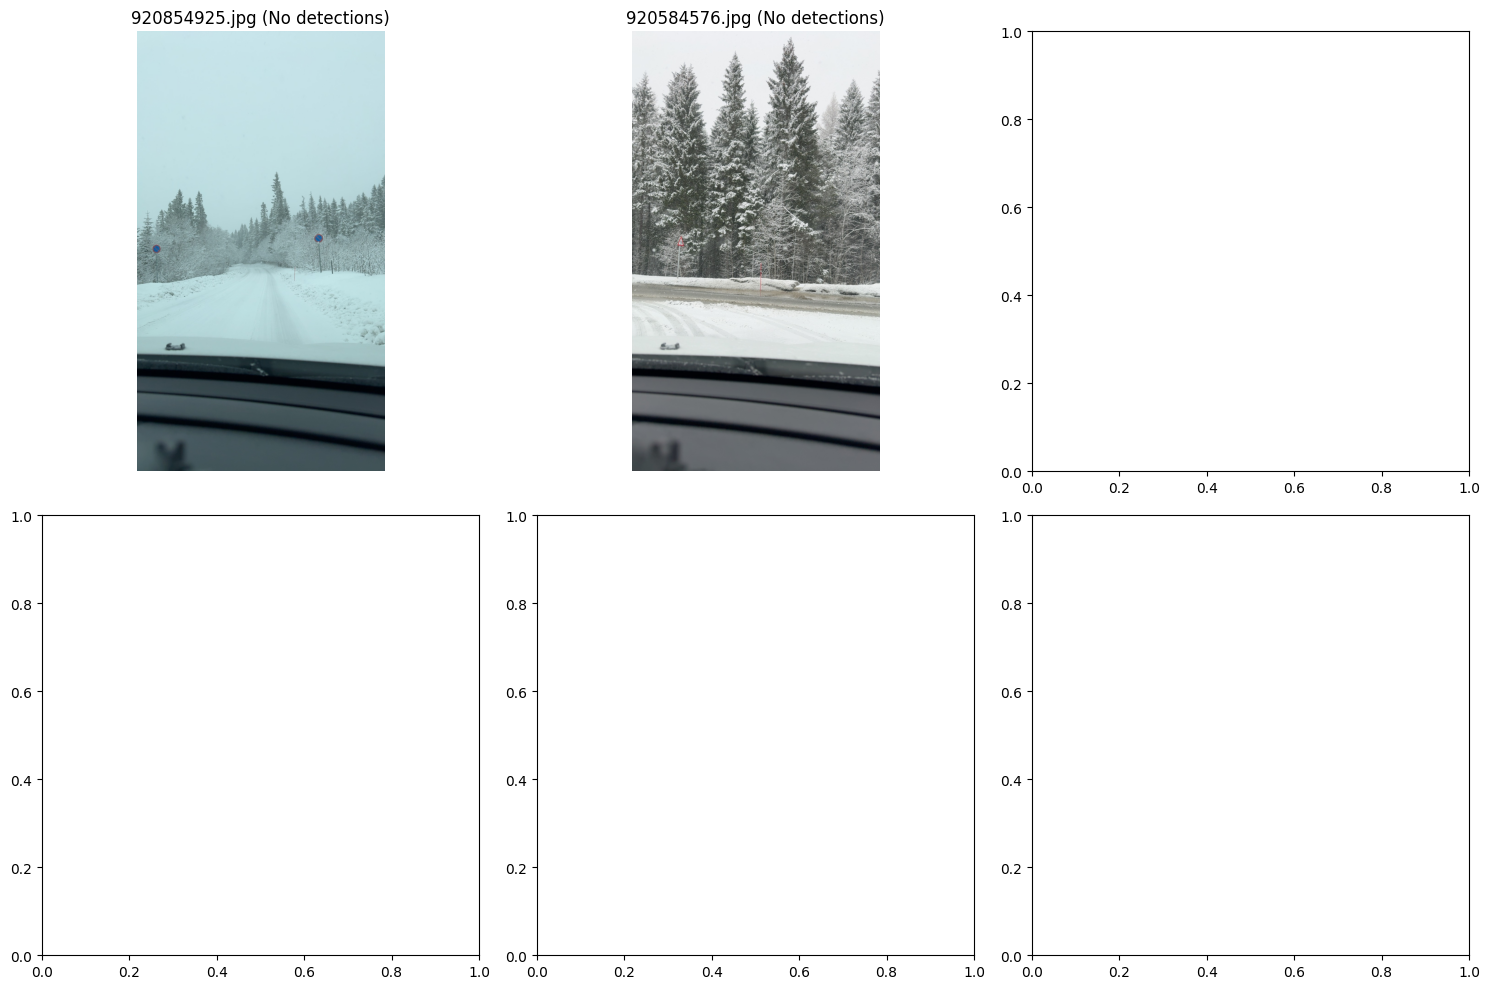

In [10]:
# Images with no detections
if inference_data:
    no_detections = [r for r in inference_data['results'] if r['n_detections'] == 0]
    
    if no_detections:
        num_samples = min(6, len(no_detections))
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()
        
        samples = random.sample(no_detections, num_samples)
        
        for idx, result in enumerate(samples):
            ax = axes[idx]
            img = cv2.imread(result['image_path'])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(f"{result['image_name']} (No detections)")
            ax.axis('off')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'no_detections.png', dpi=150, bbox_inches='tight')
        print(f"✓ Saved: no_detections.png ({len(no_detections)} images without detections)")
        plt.show()

## 5. Export Results

In [11]:
# Export results to CSV and JSON
def export_results(inference_data, output_dir):
    """Export detection results to CSV and JSON."""
    if not inference_data:
        return None
    
    results = inference_data['results']
    
    # Create DataFrame
    rows = []
    for r in results:
        if r['n_detections'] > 0:
            for i, box in enumerate(r['boxes']):
                rows.append({
                    'image': r['image_name'],
                    'detection_id': i,
                    'confidence': box['conf'],
                    'x1': box['xyxy'][0],
                    'y1': box['xyxy'][1],
                    'x2': box['xyxy'][2],
                    'y2': box['xyxy'][3],
                })
        else:
            rows.append({
                'image': r['image_name'],
                'detection_id': None,
                'confidence': None,
                'x1': None,
                'y1': None,
                'x2': None,
                'y2': None,
            })
    
    df = pd.DataFrame(rows)
    
    # Save CSV
    csv_path = output_dir / 'road_poles_iphone_detections.csv'
    df.to_csv(csv_path, index=False)
    print(f"✓ Saved CSV: {csv_path}")
    
    # Save JSON summary
    summary = {
        'dataset': 'Road_poles_iPhone (test set)',
        'model': str(MODEL_PATH),
        'timestamp': datetime.now().isoformat(),
        'config': {
            'conf_threshold': CONF_THRESHOLD,
            'iou_threshold': IOU_THRESHOLD,
            'img_size': IMG_SIZE
        },
        'statistics': {
            'total_images': len(results),
            'total_detections': sum(inference_data['detection_counts']),
            'images_with_detections': sum(1 for c in inference_data['detection_counts'] if c > 0),
            'images_without_detections': sum(1 for c in inference_data['detection_counts'] if c == 0),
            'avg_detections_per_image': float(np.mean(inference_data['detection_counts'])),
            'avg_confidence': float(np.mean(inference_data['confidences'])) if inference_data['confidences'] else 0,
            'min_confidence': float(min(inference_data['confidences'])) if inference_data['confidences'] else 0,
            'max_confidence': float(max(inference_data['confidences'])) if inference_data['confidences'] else 0,
        }
    }
    
    json_path = output_dir / 'road_poles_iphone_results_summary.json'
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"✓ Saved JSON: {json_path}")
    
    return df

if inference_data:
    results_df = export_results(inference_data, OUTPUT_DIR)
    print("\nResults preview:")
    display(results_df.head(10))

✓ Saved CSV: road_poles_iphone_test_results/road_poles_iphone_detections.csv
✓ Saved JSON: road_poles_iphone_test_results/road_poles_iphone_results_summary.json

Results preview:


,image,detection_id,confidence,x1,y1,x2,y2
0,919176034.jpg,0.0,0.922712,984.229614,888.870850,1029.075073,1024.470703
1,919190302.jpg,0.0,0.845921,1044.953369,874.309204,1075.460938,1024.914917
2,919855475.jpg,0.0,0.797785,851.559937,1040.961426,865.972168,1200.119873
3,919858142.jpg,0.0,0.311371,874.132812,1037.251831,882.041138,1180.909424
4,919858275.jpg,0.0,0.526919,945.590332,1016.357117,954.807312,1209.515869
5,919947215.jpg,0.0,0.778891,1035.385986,999.358521,1050.295898,1211.324463
6,919981218.jpg,0.0,0.876495,898.009094,1025.324463,920.465149,1193.249756
7,919981485.jpg,0.0,0.867621,1028.123535,1015.799194,1055.309082,1268.541504
8,920021754.jpg,0.0,0.869995,70.053513,1045.797485,88.829933,1146.314697
9,920044823.jpg,0.0,0.897208,60.524769,983.815552,78.516190,1086.688232


## 6. Summary

In [12]:
print(f"\n{'='*60}")
print("ROAD_POLES_IPHONE TEST SET TESTING COMPLETE")
print(f"{'='*60}")

if inference_data:
    dc = inference_data['detection_counts']
    conf = inference_data['confidences']
    
    print(f"""
Model: {MODEL_PATH.name if MODEL_PATH else 'N/A'}
Dataset: Road_poles_iPhone test set ({len(dc)} images)

RESULTS:
  Total detections: {sum(dc)}
  Detection rate: {sum(1 for c in dc if c > 0) / len(dc) * 100:.1f}%
  Avg detections/image: {np.mean(dc):.2f}
  Avg confidence: {(np.mean(conf) if conf else 0):.3f}

OUTPUT FILES:
  - {OUTPUT_DIR}/detection_statistics.png
  - {OUTPUT_DIR}/sample_detections.png
  - {OUTPUT_DIR}/no_detections.png
  - {OUTPUT_DIR}/road_poles_iphone_detections.csv
  - {OUTPUT_DIR}/road_poles_iphone_results_summary.json
    """)
else:
    print("\n⚠️ No inference results available!")
    print("Please check:")
    print("  1. Model path is correct")
    print("  2. Test images path is correct")

print(f"{'='*60}")


ROAD_POLES_IPHONE TEST SET TESTING COMPLETE

Model: best.pt
Dataset: Road_poles_iPhone test set (138 images)

RESULTS:
  Total detections: 186
  Detection rate: 98.6%
  Avg detections/image: 1.35
  Avg confidence: 0.793

OUTPUT FILES:
  - road_poles_iphone_test_results/detection_statistics.png
  - road_poles_iphone_test_results/sample_detections.png
  - road_poles_iphone_test_results/no_detections.png
  - road_poles_iphone_test_results/road_poles_iphone_detections.csv
  - road_poles_iphone_test_results/road_poles_iphone_results_summary.json
    
